# GNNExplainer Variance Analysis

Analyse der Feature- und Edge-Importances ?ber mehrere Seeds mit GNNExplainer.
Graphselektion: gesamter Datensatz (`full_dataset`), ein Graph pro `compound`.
Artefakte werden unter `results/variance/` gespeichert.


## Setup


In [25]:
import sys
import json
import math
import random
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer
from torch_geometric.explain.config import (
    ModelConfig,
    ModelMode,
    ModelReturnType,
    ModelTaskLevel,
)


def _resolve_project_root() -> Path:
    cwd = Path.cwd()
    candidates = [cwd, cwd.parent, cwd / "gnn4nmr", cwd.parent / "gnn4nmr"]
    for candidate in candidates:
        if (candidate / "scripts").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError(
        f"Could not resolve project root from cwd={cwd}. Expected a folder with scripts/ and notebooks/."
    )


PROJECT_ROOT = _resolve_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR = PROJECT_ROOT / "data"

for path in [str(PROJECT_ROOT), str(SCRIPTS_DIR), str(NOTEBOOK_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)


from scripts.explainer.experiments_evaluation import (
    build_default_context,
    select_scope_graph_indices,
    first_graph_indices_per_component,
)
from scripts.explainer.explainer_utils import (
    NodeTypeRegressionWrapper,
    get_device,
    load_config,
    load_stats,
    build_dataset,
    load_trained_model,
    heterodata_to_dicts,
)


try:
    from feature_visualization import get_feature_names as _get_feature_names
except Exception:
    _get_feature_names = None


def set_all_seeds(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass


def clone_edge_attr_dict(edge_attr_dict):
    if edge_attr_dict is None:
        return None
    return {
        edge_type: (attrs.clone() if attrs is not None else None)
        for edge_type, attrs in edge_attr_dict.items()
    }


def tensor_to_numpy(value) -> np.ndarray:
    if value is None:
        return np.asarray([], dtype=float)
    if isinstance(value, torch.Tensor):
        arr = value.detach().cpu().numpy().astype(float)
    else:
        arr = np.asarray(value, dtype=float)
    arr = np.where(np.isfinite(arr), arr, 0.0)
    return arr


def edge_type_sort_key(edge_type):
    src, rel, dst = edge_type
    return (str(src), str(rel), str(dst))


def extract_feature_vectors(explanation, feature_node_types=("H", "C")):
    vectors = {}
    node_mask_dict = getattr(explanation, "node_mask_dict", {}) or {}
    for node_type in feature_node_types:
        mask = node_mask_dict.get(node_type)
        arr = tensor_to_numpy(mask)
        if arr.ndim == 0:
            arr = arr.reshape(1)
        if arr.ndim == 1:
            vec = arr.reshape(-1)
        elif arr.ndim >= 2:
            arr2 = arr.reshape(arr.shape[0], -1)
            vec = arr2.mean(axis=0)
        else:
            vec = np.asarray([], dtype=float)
        vectors[node_type] = np.asarray(vec, dtype=float).reshape(-1)
    return vectors


def build_edge_vector(explanation, edge_index_dict):
    edge_mask_dict = getattr(explanation, "edge_mask_dict", {}) or {}
    values = []

    for edge_type in sorted(edge_index_dict.keys(), key=edge_type_sort_key):
        num_edges = int(edge_index_dict[edge_type].size(1))
        mask = edge_mask_dict.get(edge_type)
        mask_arr = tensor_to_numpy(mask).reshape(-1)

        for pos in range(num_edges):
            if pos < int(mask_arr.size):
                value = float(mask_arr[pos])
                values.append(value if np.isfinite(value) else 0.0)
            else:
                values.append(0.0)

    return np.asarray(values, dtype=float)


def pad_and_stack(vectors):
    arrs = [np.asarray(v, dtype=float).reshape(-1) for v in vectors]
    if not arrs:
        return np.zeros((0, 0), dtype=float)
    max_dim = max(int(a.size) for a in arrs)
    if max_dim <= 0:
        return np.zeros((len(arrs), 0), dtype=float)
    mat = np.zeros((len(arrs), max_dim), dtype=float)
    for i, arr in enumerate(arrs):
        if arr.size > 0:
            mat[i, : int(arr.size)] = np.where(np.isfinite(arr), arr, 0.0)
    return mat


def vector_stats(vectors):
    mat = pad_and_stack(vectors)
    if mat.shape[0] == 0 or mat.shape[1] == 0:
        return np.asarray([], dtype=float), np.asarray([], dtype=float)

    mean_vec = np.mean(mat, axis=0)
    if mat.shape[0] < 2:
        var_vec = np.full(mean_vec.shape, np.nan, dtype=float)
    else:
        var_vec = np.var(mat, axis=0, ddof=0)

    return np.asarray(mean_vec, dtype=float), np.asarray(var_vec, dtype=float)


def vector_mean(vectors):
    dim_mean, _ = vector_stats(vectors)
    return dim_mean


def vector_variance(vectors):
    _, dim_var = vector_stats(vectors)
    return dim_var


def mean_dim_variance(vectors):
    dim_var = vector_variance(vectors)
    finite = dim_var[np.isfinite(dim_var)]
    if finite.size == 0:
        return float("nan")
    return float(np.mean(finite))


def mean_dim_value(vectors):
    dim_mean = vector_mean(vectors)
    finite = dim_mean[np.isfinite(dim_mean)]
    if finite.size == 0:
        return float("nan")
    return float(np.mean(finite))


def collect_candidate_nodes(dataset, eval_graph_indices, node_types=("H", "C"), explanation_type="phenomenon"):
    rows = []
    explanation_type = str(explanation_type).strip().lower()

    for graph_idx in sorted(int(i) for i in eval_graph_indices):
        data = dataset[graph_idx]

        for node_type in node_types:
            if node_type not in data.node_types:
                continue

            x = data[node_type].x
            num_nodes = int(x.size(0))
            if num_nodes <= 0:
                continue

            y_tensor = getattr(data[node_type], "y", None)
            y_flat = y_tensor.reshape(-1) if isinstance(y_tensor, torch.Tensor) else None

            if explanation_type == "phenomenon" and y_flat is None:
                continue

            for node_idx in range(num_nodes):
                target_value = float("nan")
                if y_flat is not None and node_idx < int(y_flat.numel()):
                    target_value = float(y_flat[node_idx].item())

                if explanation_type == "phenomenon" and not np.isfinite(target_value):
                    continue

                rows.append(
                    {
                        "graph_idx": int(graph_idx),
                        "target_node_type": str(node_type),
                        "node_idx": int(node_idx),
                        "target_value": float(target_value),
                    }
                )

    return rows


def safe_feature_name(node_type: str, feature_idx: int) -> str:
    if callable(_get_feature_names):
        try:
            names = list(_get_feature_names(node_type))
            if 0 <= int(feature_idx) < len(names):
                return str(names[int(feature_idx)])
        except Exception:
            pass
    return f"feature_{node_type}_{int(feature_idx)}"


print(f"cwd: {Path.cwd()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Models dir: {MODELS_DIR}")
print(f"Data dir: {DATA_DIR}")


cwd: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\notebooks
Project root: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr
Notebook dir: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\notebooks
Models dir: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\models
Data dir: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\data


In [26]:
def _pick_default_file(directory: Path, pattern: str, preferred: str):
    preferred_path = directory / preferred
    if preferred_path.exists():
        return preferred
    matches = sorted(p.name for p in directory.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No files matching {pattern!r} found in {directory}")
    return matches[0]


MODEL_FILE = _pick_default_file(MODELS_DIR, "*.pt", "GraphConv_best_model.pt")
DATA_FILE = _pick_default_file(DATA_DIR, "*.pkl", "all_graphs_with_length_filtered.pkl")
SPLIT_FILE = "models/graph_split.pkl"

GRAPH_SCOPE = "full_dataset"
FIRST_GRAPH_PER_COMPONENT = True
COMPONENT_KEY = "compound"

NODE_TYPES = ("H", "C")
REPEATS = 5
SEEDS = [0, 1, 2, 3, 4]
assert len(SEEDS) == REPEATS, "SEEDS and REPEATS mismatch"

# Optional limits (0 means no limit)
MAX_GRAPHS = 0
MAX_NODES_PER_GRAPH = 0

GNN_EPOCHS = 200
GNN_LR = 0.01
GNN_EXPLANATION_TYPE = "phenomenon"

OUTPUT_DIR = PROJECT_ROOT / "results" / "variance"
PLOTS_DIR = OUTPUT_DIR / "plots"

TOP_N_FEATURES_PLOT = 30
FIG_DPI = 180

COLOR_BLUE = "#004e9f"
COLOR_YELLOW = "#fcba00"
COLOR_GREY = "#909085"

print("Variance config loaded")
print(f"MODEL_FILE={MODEL_FILE}")
print(f"DATA_FILE={DATA_FILE}")
print(f"SPLIT_FILE={SPLIT_FILE}")
print(f"GRAPH_SCOPE={GRAPH_SCOPE}")
print(f"FIRST_GRAPH_PER_COMPONENT={FIRST_GRAPH_PER_COMPONENT}, COMPONENT_KEY={COMPONENT_KEY}")
print(f"NODE_TYPES={NODE_TYPES}, REPEATS={REPEATS}, SEEDS={SEEDS}")
print(f"MAX_GRAPHS={MAX_GRAPHS}, MAX_NODES_PER_GRAPH={MAX_NODES_PER_GRAPH}")
print(f"GNN settings: epochs={GNN_EPOCHS}, lr={GNN_LR}, explanation_type={GNN_EXPLANATION_TYPE}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")


Variance config loaded
MODEL_FILE=GraphConv_best_model.pt
DATA_FILE=all_graphs_with_length_filtered.pkl
SPLIT_FILE=models/graph_split.pkl
GRAPH_SCOPE=full_dataset
FIRST_GRAPH_PER_COMPONENT=True, COMPONENT_KEY=compound
NODE_TYPES=('H', 'C'), REPEATS=5, SEEDS=[0, 1, 2, 3, 4]
MAX_GRAPHS=0, MAX_NODES_PER_GRAPH=0
GNN settings: epochs=200, lr=0.01, explanation_type=phenomenon
OUTPUT_DIR=c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\variance


## Varianzberechnung


In [5]:
context = build_default_context(
    project_root=PROJECT_ROOT,
    model_file=MODEL_FILE,
    data_file=DATA_FILE,
    split_file=SPLIT_FILE,
    output_dir=str(OUTPUT_DIR),
)

device = get_device(None)
config = load_config(str(context.config_path))
norm_stats, edge_stats = load_stats(str(context.norm_stats_path), str(context.edge_stats_path))
dataset = build_dataset(str(context.data_path), config, norm_stats=norm_stats, edge_stats=edge_stats)
base_model = load_trained_model(str(context.model_path), config, device)

scope_graph_indices = select_scope_graph_indices(
    dataset=dataset,
    split_path=context.split_path,
    graph_scope=GRAPH_SCOPE,
)

scope_compounds = []
for graph_idx in scope_graph_indices:
    nx_g = dataset.nx_graphs[int(graph_idx)]
    scope_compounds.append(str(nx_g.graph.get(COMPONENT_KEY, "unknown")))
scope_unique_compounds = sorted(set(scope_compounds))
scope_unique_compounds_count = int(len(scope_unique_compounds))

if FIRST_GRAPH_PER_COMPONENT:
    eval_graph_indices = first_graph_indices_per_component(
        dataset=dataset,
        graph_indices=scope_graph_indices,
        component_key=COMPONENT_KEY,
    )
else:
    eval_graph_indices = [int(i) for i in scope_graph_indices]

if int(MAX_GRAPHS) > 0:
    eval_graph_indices = eval_graph_indices[: int(MAX_GRAPHS)]

candidate_nodes = collect_candidate_nodes(
    dataset=dataset,
    eval_graph_indices=eval_graph_indices,
    node_types=NODE_TYPES,
    explanation_type=GNN_EXPLANATION_TYPE,
)

if int(MAX_NODES_PER_GRAPH) > 0:
    grouped = defaultdict(list)
    for row in candidate_nodes:
        grouped[(int(row["graph_idx"]), str(row["target_node_type"]))].append(row)

    reduced = []
    rng = random.Random(0)
    for key in sorted(grouped.keys()):
        rows = grouped[key]
        if len(rows) > int(MAX_NODES_PER_GRAPH):
            pick_idx = sorted(rng.sample(range(len(rows)), int(MAX_NODES_PER_GRAPH)))
            rows = [rows[i] for i in pick_idx]
        reduced.extend(rows)

    candidate_nodes = sorted(
        reduced,
        key=lambda x: (int(x["graph_idx"]), str(x["target_node_type"]), int(x["node_idx"])),
    )


graph_meta_rows = []
for graph_idx in eval_graph_indices:
    data = dataset[int(graph_idx)]
    num_nodes = sum(int(data[nt].x.size(0)) for nt in data.node_types)
    num_edges = sum(int(store.edge_index.size(1)) for store in data.edge_stores)
    compound = dataset.nx_graphs[int(graph_idx)].graph.get(COMPONENT_KEY, "unknown")
    graph_meta_rows.append(
        {
            "graph_idx": int(graph_idx),
            "compound": str(compound),
            "graph_num_nodes": int(num_nodes),
            "graph_num_edges": int(num_edges),
        }
    )

graph_meta_df = pd.DataFrame(graph_meta_rows).sort_values("graph_idx").reset_index(drop=True)
graph_meta_map = {
    int(row["graph_idx"]): row
    for row in graph_meta_df.to_dict(orient="records")
}

graph_cache = {}
for graph_idx in eval_graph_indices:
    data = dataset[int(graph_idx)].to(device)
    x_dict_raw, edge_index_dict, edge_attr_dict_raw, y_dict_raw = heterodata_to_dicts(data)

    x_dict = {nt: feat.clone() for nt, feat in x_dict_raw.items()}
    edge_attr_dict = clone_edge_attr_dict(edge_attr_dict_raw)
    y_dict = {
        nt: (val.clone() if isinstance(val, torch.Tensor) else val)
        for nt, val in y_dict_raw.items()
    }

    graph_cache[int(graph_idx)] = {
        "x_dict": x_dict,
        "edge_index_dict": edge_index_dict,
        "edge_attr_dict": edge_attr_dict,
        "y_dict": y_dict,
    }

print(f"Device: {device}")
print(f"Dataset size: {len(dataset)}")
print(f"Graphs in scope before component filter: {len(scope_graph_indices)}")
print(f"Unique compounds in scope: {scope_unique_compounds_count}")
print(f"Graphs selected for evaluation: {len(eval_graph_indices)}")
print(f"Candidate nodes selected: {len(candidate_nodes)}")
print("Node counts by target type:")
print(pd.Series([row["target_node_type"] for row in candidate_nodes]).value_counts())

display(graph_meta_df.head(10))


Device: cpu
Dataset size: 712
Graphs in scope before component filter: 712
Unique compounds in scope: 73
Graphs selected for evaluation: 73
Candidate nodes selected: 795
Node counts by target type:
H    487
C    308
Name: count, dtype: int64


c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\scripts\explainer\explainer_utils.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(model_path, map_location=device)


,graph_idx,compound,graph_num_nodes,graph_num_edges
0,0,1,11,20
1,10,2,12,24
2,20,3,12,24
3,30,4,13,26
4,40,5,13,24
5,50,6,14,30
6,60,7,15,28
7,70,8,15,32
8,80,9,17,34
9,90,10,17,36


In [6]:
model_config = ModelConfig(
    mode=ModelMode.regression,
    task_level=ModelTaskLevel.node,
    return_type=ModelReturnType.raw,
)

explanation_rows = []
failure_rows = []

feature_vectors_by_node = defaultdict(lambda: {nt: [] for nt in NODE_TYPES})
edge_vectors_by_node = defaultdict(list)
seed_runs_by_node = defaultdict(set)
target_value_by_node = {}

for seed in SEEDS:
    set_all_seeds(seed)

    explainers = {}
    for target_node_type in NODE_TYPES:
        wrapped_model = NodeTypeRegressionWrapper(base_model, target_node_type)
        explainers[target_node_type] = Explainer(
            model=wrapped_model,
            algorithm=GNNExplainer(epochs=int(GNN_EPOCHS), lr=float(GNN_LR)),
            explanation_type=str(GNN_EXPLANATION_TYPE),
            model_config=model_config,
            node_mask_type="attributes",
            edge_mask_type="object",
        )

    print(f"Seed {seed}: explaining {len(candidate_nodes)} nodes")

    for row in candidate_nodes:
        graph_idx = int(row["graph_idx"])
        target_node_type = str(row["target_node_type"])
        node_idx = int(row["node_idx"])
        target_value = float(row.get("target_value", float("nan")))

        cache_item = graph_cache.get(graph_idx)
        if cache_item is None:
            failure_rows.append(
                {
                    "seed": int(seed),
                    "graph_idx": int(graph_idx),
                    "target_node_type": target_node_type,
                    "node_idx": int(node_idx),
                    "error": "graph_cache_missing",
                }
            )
            continue

        x_dict = {nt: feat.clone() for nt, feat in cache_item["x_dict"].items()}
        edge_index_dict = cache_item["edge_index_dict"]
        edge_attr_dict = clone_edge_attr_dict(cache_item["edge_attr_dict"])
        y_dict = cache_item["y_dict"]

        gnn_target = None
        if str(GNN_EXPLANATION_TYPE).strip().lower() == "phenomenon":
            y_tensor = y_dict.get(target_node_type)
            if y_tensor is None:
                failure_rows.append(
                    {
                        "seed": int(seed),
                        "graph_idx": int(graph_idx),
                        "target_node_type": target_node_type,
                        "node_idx": int(node_idx),
                        "error": "missing_target_tensor",
                    }
                )
                continue

            y_tensor = y_tensor.reshape(-1)
            if node_idx < 0 or node_idx >= int(y_tensor.size(0)):
                failure_rows.append(
                    {
                        "seed": int(seed),
                        "graph_idx": int(graph_idx),
                        "target_node_type": target_node_type,
                        "node_idx": int(node_idx),
                        "error": "node_idx_out_of_bounds",
                    }
                )
                continue
            if torch.isnan(y_tensor[node_idx]):
                failure_rows.append(
                    {
                        "seed": int(seed),
                        "graph_idx": int(graph_idx),
                        "target_node_type": target_node_type,
                        "node_idx": int(node_idx),
                        "error": "target_is_nan",
                    }
                )
                continue

            gnn_target = y_tensor

        try:
            try:
                explanation = explainers[target_node_type](
                    x_dict,
                    edge_index_dict,
                    edge_attr_dict=edge_attr_dict,
                    target=gnn_target,
                    index=node_idx,
                )
            except Exception as inner_exc:
                if str(GNN_EXPLANATION_TYPE).strip().lower() == "phenomenon" and gnn_target is not None:
                    explanation = explainers[target_node_type](
                        x_dict,
                        edge_index_dict,
                        edge_attr_dict=edge_attr_dict,
                        target=gnn_target[node_idx],
                        index=node_idx,
                    )
                else:
                    raise inner_exc

            feature_vectors = extract_feature_vectors(
                explanation,
                feature_node_types=NODE_TYPES,
            )
            feature_h = np.asarray(feature_vectors.get("H", np.asarray([], dtype=float)), dtype=float).reshape(-1)
            feature_c = np.asarray(feature_vectors.get("C", np.asarray([], dtype=float)), dtype=float).reshape(-1)
            edge_vector = build_edge_vector(explanation, edge_index_dict).reshape(-1)

            meta = graph_meta_map.get(graph_idx, {})
            explanation_rows.append(
                {
                    "seed": int(seed),
                    "graph_idx": int(graph_idx),
                    "compound": str(meta.get("compound", "unknown")),
                    "graph_num_nodes": int(meta.get("graph_num_nodes", 0)),
                    "graph_num_edges": int(meta.get("graph_num_edges", 0)),
                    "target_node_type": target_node_type,
                    "node_idx": int(node_idx),
                    "target_value": float(target_value),
                    "feature_h_dim": int(feature_h.size),
                    "feature_c_dim": int(feature_c.size),
                    "edge_dim": int(edge_vector.size),
                    "feature_h_vector": json.dumps(feature_h.tolist()),
                    "feature_c_vector": json.dumps(feature_c.tolist()),
                    "edge_vector": json.dumps(edge_vector.tolist()),
                }
            )

            key = (int(graph_idx), target_node_type, int(node_idx))
            feature_vectors_by_node[key]["H"].append(feature_h)
            feature_vectors_by_node[key]["C"].append(feature_c)
            edge_vectors_by_node[key].append(edge_vector)
            seed_runs_by_node[key].add(int(seed))
            target_value_by_node[key] = float(target_value)

        except Exception as exc:
            failure_rows.append(
                {
                    "seed": int(seed),
                    "graph_idx": int(graph_idx),
                    "target_node_type": target_node_type,
                    "node_idx": int(node_idx),
                    "error": str(exc),
                }
            )


explanation_runs_df = pd.DataFrame(explanation_rows)
failures_df = pd.DataFrame(failure_rows)

feature_dim_rows = []
edge_dim_rows = []
node_variance_rows = []

for key in sorted(seed_runs_by_node.keys()):
    graph_idx, target_node_type, node_idx = key
    meta = graph_meta_map.get(graph_idx, {})

    feature_var_mean = {}
    feature_imp_mean = {}

    for feature_source_type in NODE_TYPES:
        vectors = feature_vectors_by_node[key].get(feature_source_type, [])
        dim_mean, dim_var = vector_stats(vectors)

        if dim_mean.size > 0:
            for feature_idx in range(int(dim_mean.size)):
                var_value = float(dim_var[feature_idx]) if feature_idx < int(dim_var.size) else float("nan")
                feature_dim_rows.append(
                    {
                        "graph_idx": int(graph_idx),
                        "compound": str(meta.get("compound", "unknown")),
                        "target_node_type": str(target_node_type),
                        "node_idx": int(node_idx),
                        "feature_source_type": str(feature_source_type),
                        "feature_idx": int(feature_idx),
                        "feature_importance_mean": float(dim_mean[feature_idx]),
                        "feature_variance": var_value,
                    }
                )

            finite_var = dim_var[np.isfinite(dim_var)]
            finite_mean = dim_mean[np.isfinite(dim_mean)]
            feature_var_mean[feature_source_type] = float(np.mean(finite_var)) if finite_var.size > 0 else float("nan")
            feature_imp_mean[feature_source_type] = float(np.mean(finite_mean)) if finite_mean.size > 0 else float("nan")
        else:
            feature_var_mean[feature_source_type] = float("nan")
            feature_imp_mean[feature_source_type] = float("nan")

    edge_mean_vec, edge_var_vec = vector_stats(edge_vectors_by_node.get(key, []))
    if edge_mean_vec.size > 0:
        for edge_idx in range(int(edge_mean_vec.size)):
            var_value = float(edge_var_vec[edge_idx]) if edge_idx < int(edge_var_vec.size) else float("nan")
            edge_dim_rows.append(
                {
                    "graph_idx": int(graph_idx),
                    "compound": str(meta.get("compound", "unknown")),
                    "target_node_type": str(target_node_type),
                    "node_idx": int(node_idx),
                    "edge_idx": int(edge_idx),
                    "edge_importance_mean": float(edge_mean_vec[edge_idx]),
                    "edge_variance": var_value,
                }
            )

    finite_edge_var = edge_var_vec[np.isfinite(edge_var_vec)]
    finite_edge_mean = edge_mean_vec[np.isfinite(edge_mean_vec)]
    edge_var_mean = float(np.mean(finite_edge_var)) if finite_edge_var.size > 0 else float("nan")
    edge_imp_mean = float(np.mean(finite_edge_mean)) if finite_edge_mean.size > 0 else float("nan")

    finite_vals = [
        v
        for v in [feature_var_mean.get("H"), feature_var_mean.get("C"), edge_var_mean]
        if np.isfinite(v)
    ]
    overall_var_mean = float(np.mean(finite_vals)) if finite_vals else float("nan")

    node_variance_rows.append(
        {
            "graph_idx": int(graph_idx),
            "compound": str(meta.get("compound", "unknown")),
            "graph_num_nodes": int(meta.get("graph_num_nodes", 0)),
            "graph_num_edges": int(meta.get("graph_num_edges", 0)),
            "target_node_type": str(target_node_type),
            "node_idx": int(node_idx),
            "target_value": float(target_value_by_node.get(key, float("nan"))),
            "seed_runs": int(len(seed_runs_by_node.get(key, set()))),
            "feature_imp_mean_H": float(feature_imp_mean.get("H", float("nan"))),
            "feature_imp_mean_C": float(feature_imp_mean.get("C", float("nan"))),
            "feature_var_mean_H": float(feature_var_mean.get("H", float("nan"))),
            "feature_var_mean_C": float(feature_var_mean.get("C", float("nan"))),
            "edge_imp_mean": float(edge_imp_mean),
            "edge_var_mean": float(edge_var_mean),
            "overall_var_mean": float(overall_var_mean),
        }
    )


feature_importance_dim_df = pd.DataFrame(feature_dim_rows)
edge_importance_dim_df = pd.DataFrame(edge_dim_rows)
node_variance_df = pd.DataFrame(node_variance_rows)

if feature_importance_dim_df.empty:
    feature_variance_by_target_df = pd.DataFrame(
        columns=[
            "target_node_type",
            "feature_source_type",
            "feature_idx",
            "feature_importance_mean",
            "feature_importance_median",
            "feature_importance_std",
            "feature_variance_mean",
            "feature_variance_median",
            "feature_variance_std",
            "n_node_entries",
            "feature_name",
            "feature_label",
        ]
    )
else:
    feature_variance_by_target_df = (
        feature_importance_dim_df.groupby(
            ["target_node_type", "feature_source_type", "feature_idx"],
            as_index=False,
        )
        .agg(
            feature_importance_mean=("feature_importance_mean", "mean"),
            feature_importance_median=("feature_importance_mean", "median"),
            feature_importance_std=(
                "feature_importance_mean",
                lambda s: float(np.std(pd.to_numeric(s, errors="coerce").dropna().to_numpy(dtype=float), ddof=0)),
            ),
            feature_variance_mean=("feature_variance", "mean"),
            feature_variance_median=("feature_variance", "median"),
            feature_variance_std=(
                "feature_variance",
                lambda s: float(np.std(pd.to_numeric(s, errors="coerce").dropna().to_numpy(dtype=float), ddof=0)),
            ),
            n_node_entries=("feature_importance_mean", "size"),
        )
        .sort_values(["target_node_type", "feature_importance_mean"], ascending=[True, False])
        .reset_index(drop=True)
    )

    feature_variance_by_target_df["feature_name"] = feature_variance_by_target_df.apply(
        lambda row: safe_feature_name(str(row["feature_source_type"]), int(row["feature_idx"])),
        axis=1,
    )
    feature_variance_by_target_df["feature_label"] = feature_variance_by_target_df.apply(
        lambda row: f"{row['feature_source_type']}:{row['feature_name']}",
        axis=1,
    )


if node_variance_df.empty:
    graph_edge_variance_df = pd.DataFrame(
        columns=[
            "graph_idx",
            "compound",
            "graph_num_nodes",
            "graph_num_edges",
            "explained_nodes",
            "graph_edge_importance_mean",
            "graph_edge_var_mean",
            "graph_edge_var_median",
            "graph_edge_var_std",
        ]
    )
else:
    graph_edge_variance_df = (
        node_variance_df.groupby("graph_idx", as_index=False)
        .agg(
            compound=("compound", "first"),
            graph_num_nodes=("graph_num_nodes", "first"),
            graph_num_edges=("graph_num_edges", "first"),
            explained_nodes=("node_idx", "count"),
            graph_edge_importance_mean=("edge_imp_mean", "mean"),
            graph_edge_var_mean=("edge_var_mean", "mean"),
            graph_edge_var_median=("edge_var_mean", "median"),
            graph_edge_var_std=(
                "edge_var_mean",
                lambda s: float(np.std(pd.to_numeric(s, errors="coerce").dropna().to_numpy(dtype=float), ddof=0)),
            ),
        )
        .sort_values("graph_idx")
        .reset_index(drop=True)
    )

print("Computation finished")
print(f"explanation_runs_df: {explanation_runs_df.shape}")
print(f"node_variance_df: {node_variance_df.shape}")
print(f"feature_importance_dim_df: {feature_importance_dim_df.shape}")
print(f"edge_importance_dim_df: {edge_importance_dim_df.shape}")
print(f"feature_variance_by_target_df: {feature_variance_by_target_df.shape}")
print(f"graph_edge_variance_df: {graph_edge_variance_df.shape}")
print(f"failures_df: {failures_df.shape}")

display(node_variance_df.head(10))
display(feature_variance_by_target_df.head(10))
display(graph_edge_variance_df.head(10))


Seed 0: explaining 795 nodes


KeyboardInterrupt: 

In [7]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

explanation_runs_path = OUTPUT_DIR / "explanation_runs_raw.csv"
node_variance_path = OUTPUT_DIR / "node_level_variance.csv"
feature_importance_dim_path = OUTPUT_DIR / "feature_importance_dim.csv"
edge_importance_dim_path = OUTPUT_DIR / "edge_importance_dim.csv"
feature_variance_target_path = OUTPUT_DIR / "feature_variance_by_target.csv"
graph_edge_variance_path = OUTPUT_DIR / "graph_edge_variance.csv"
failures_path = OUTPUT_DIR / "failed_explanations.csv"
run_config_path = OUTPUT_DIR / "run_config.json"

explanation_runs_df.to_csv(explanation_runs_path, index=False)
node_variance_df.to_csv(node_variance_path, index=False)
feature_importance_dim_df.to_csv(feature_importance_dim_path, index=False)
edge_importance_dim_df.to_csv(edge_importance_dim_path, index=False)
feature_variance_by_target_df.to_csv(feature_variance_target_path, index=False)
graph_edge_variance_df.to_csv(graph_edge_variance_path, index=False)
failures_df.to_csv(failures_path, index=False)

run_config = {
    "model_file": str(MODEL_FILE),
    "data_file": str(DATA_FILE),
    "split_file": str(SPLIT_FILE),
    "graph_scope": str(GRAPH_SCOPE),
    "first_graph_per_component": bool(FIRST_GRAPH_PER_COMPONENT),
    "component_key": str(COMPONENT_KEY),
    "node_types": [str(nt) for nt in NODE_TYPES],
    "repeats": int(REPEATS),
    "seeds": [int(s) for s in SEEDS],
    "max_graphs": int(MAX_GRAPHS),
    "max_nodes_per_graph": int(MAX_NODES_PER_GRAPH),
    "gnn_epochs": int(GNN_EPOCHS),
    "gnn_lr": float(GNN_LR),
    "gnn_explanation_type": str(GNN_EXPLANATION_TYPE),
    "output_dir": str(OUTPUT_DIR),
    "plots_dir": str(PLOTS_DIR),
    "counts": {
        "graphs_in_scope": int(len(scope_graph_indices)),
        "unique_compounds_in_scope": int(scope_unique_compounds_count),
        "graphs_selected": int(len(eval_graph_indices)),
        "candidate_nodes": int(len(candidate_nodes)),
        "run_rows": int(len(explanation_runs_df)),
        "node_variance_rows": int(len(node_variance_df)),
        "feature_importance_dim_rows": int(len(feature_importance_dim_df)),
        "edge_importance_dim_rows": int(len(edge_importance_dim_df)),
        "feature_variance_rows": int(len(feature_variance_by_target_df)),
        "graph_edge_rows": int(len(graph_edge_variance_df)),
        "failed_rows": int(len(failures_df)),
    },
    "artifacts": {
        "explanation_runs_raw": str(explanation_runs_path),
        "node_level_variance": str(node_variance_path),
        "feature_importance_dim": str(feature_importance_dim_path),
        "edge_importance_dim": str(edge_importance_dim_path),
        "feature_variance_by_target": str(feature_variance_target_path),
        "graph_edge_variance": str(graph_edge_variance_path),
        "failed_explanations": str(failures_path),
        "run_config": str(run_config_path),
    },
}

with run_config_path.open("w", encoding="utf-8") as handle:
    json.dump(run_config, handle, indent=2)

print("Saved variance artifacts:")
print(f"  {explanation_runs_path}")
print(f"  {node_variance_path}")
print(f"  {feature_importance_dim_path}")
print(f"  {edge_importance_dim_path}")
print(f"  {feature_variance_target_path}")
print(f"  {graph_edge_variance_path}")
print(f"  {failures_path}")
print(f"  {run_config_path}")


NameError: name 'explanation_runs_df' is not defined

In [7]:
print("Validation checks")

expected_graphs = int(len(eval_graph_indices))
actual_graphs = int(graph_edge_variance_df["graph_idx"].nunique()) if not graph_edge_variance_df.empty else 0
print(f"Graphs selected (scope): {expected_graphs}")
print(f"Graphs with edge variance rows: {actual_graphs}")
print(f"Unique compounds in scope: {int(scope_unique_compounds_count)}")

if expected_graphs == int(scope_unique_compounds_count):
    print("OK: selected graph count matches unique compounds in scope.")
else:
    print("WARN: selected graph count does not match unique compounds in scope.")

if explanation_runs_df.empty:
    print("No explanation rows found. Check configuration or runtime errors.")
else:
    run_counts = explanation_runs_df.groupby(["graph_idx", "target_node_type", "node_idx"])["seed"].nunique()
    print(f"Per-node unique seed runs: min={int(run_counts.min())}, max={int(run_counts.max())}, mean={float(run_counts.mean()):.2f}")

    incomplete = run_counts[run_counts < int(REPEATS)]
    if incomplete.empty:
        print("All explained nodes have full repeat coverage.")
    else:
        print(f"Nodes with incomplete repeat coverage: {int(len(incomplete))}")

numeric_checks = [
    ("feature_importance_mean", feature_variance_by_target_df),
    ("feature_variance_mean", feature_variance_by_target_df),
    ("edge_imp_mean", node_variance_df),
    ("edge_var_mean", node_variance_df),
    ("graph_edge_var_mean", graph_edge_variance_df),
]
for col, df in numeric_checks:
    if col in df.columns:
        vals = pd.to_numeric(df[col], errors="coerce")
        finite_count = int(np.isfinite(vals).sum())
        print(f"Numeric parse check: {col} finite={finite_count}/{len(df)}")

required_files = [
    OUTPUT_DIR / "explanation_runs_raw.csv",
    OUTPUT_DIR / "node_level_variance.csv",
    OUTPUT_DIR / "feature_importance_dim.csv",
    OUTPUT_DIR / "edge_importance_dim.csv",
    OUTPUT_DIR / "feature_variance_by_target.csv",
    OUTPUT_DIR / "graph_edge_variance.csv",
    OUTPUT_DIR / "run_config.json",
    PLOTS_DIR / "feature_importance_variance_stacked.png",
    PLOTS_DIR / "edge_variance_hist_and_graphsize.png",
]

for path in required_files:
    status = "OK" if path.exists() else "MISSING"
    print(f"{status:>7}  {path}")

expected_total_runs = int(len(candidate_nodes)) * int(len(SEEDS))
if expected_total_runs > 0:
    fail_rate = float(len(failures_df)) / float(expected_total_runs)
    print(f"Failure rate: {len(failures_df)}/{expected_total_runs} = {fail_rate:.2%}")
    if fail_rate > 0.10:
        print("WARN: failure rate > 10%")

if not failures_df.empty:
    print("Top failure reasons:")
    display(failures_df["error"].value_counts().head(10).to_frame("count"))


Validation checks
Graphs selected (scope): 73
Graphs with edge variance rows: 73
Unique compounds in scope: 73
OK: selected graph count matches unique compounds in scope.
Per-node unique seed runs: min=5, max=5, mean=5.00
All explained nodes have full repeat coverage.
Numeric parse check: feature_importance_mean finite=144/144
Numeric parse check: feature_variance_mean finite=144/144
Numeric parse check: edge_imp_mean finite=795/795
Numeric parse check: edge_var_mean finite=795/795
Numeric parse check: graph_edge_var_mean finite=73/73
     OK  c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\variance\explanation_runs_raw.csv
     OK  c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\variance\node_level_variance.csv
     OK  c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\variance\feature_importance_dim.csv
     OK  c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\variance\edge_importance_dim.csv
     OK  c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\variance\feature_variance_by_target.csv
     OK  c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\res

## Visualisierung

Standalone nach Setup: Diese Zelle l?dt die ben?tigten Daten direkt aus `results/variance/`.


Loaded: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\variance\feature_variance_by_target.csv
Loaded: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\variance\graph_edge_variance.csv
Saved: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\variance\plots\feature_importance_variance_stacked.png


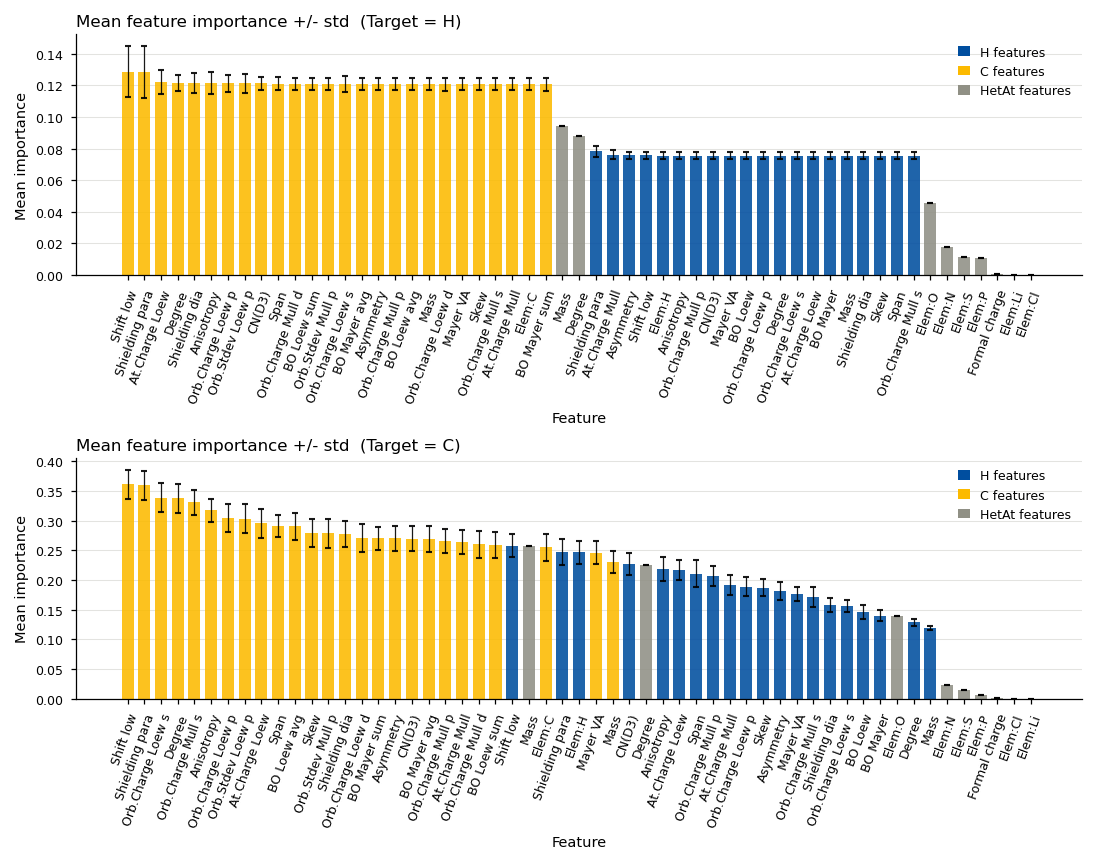

Target=H: 33 features with importance = 0 (not plotted)


,feature_display_name,feature_source_type,feature_idx,feature_importance_mean,feature_variance_mean
0,Elem:H,C,0,0.0,0.0
1,Elem:Li,C,2,0.0,0.0
2,Elem:B,C,3,0.0,0.0
3,Elem:N,C,4,0.0,0.0
4,Elem:O,C,5,0.0,0.0
5,Elem:Na,C,6,0.0,0.0
6,Elem:Mg,C,7,0.0,0.0
7,Elem:Al,C,8,0.0,0.0
8,Elem:Si,C,9,0.0,0.0
9,Elem:P,C,10,0.0,0.0


Target=C: 33 features with importance = 0 (not plotted)


,feature_display_name,feature_source_type,feature_idx,feature_importance_mean,feature_variance_mean
0,Elem:H,C,0,0.0,0.0
1,Elem:Li,C,2,0.0,0.0
2,Elem:B,C,3,0.0,0.0
3,Elem:N,C,4,0.0,0.0
4,Elem:O,C,5,0.0,0.0
5,Elem:Na,C,6,0.0,0.0
6,Elem:Mg,C,7,0.0,0.0
7,Elem:Al,C,8,0.0,0.0
8,Elem:Si,C,9,0.0,0.0
9,Elem:P,C,10,0.0,0.0


Saved: c:\Uni\Lab\gnn4nmr-lab\gnn4nmr\results\variance\plots\edge_variance_hist_and_graphsize.png


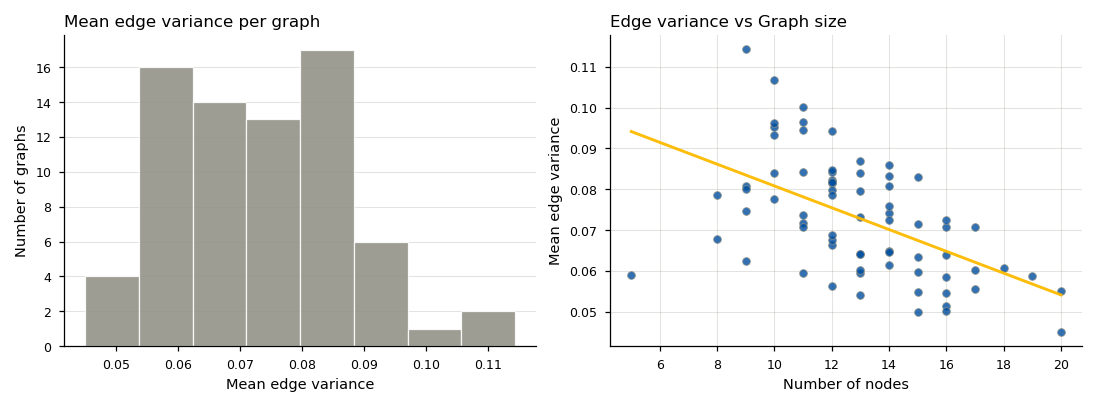

In [33]:
import matplotlib as mpl
from matplotlib.patches import Patch

# --- Publication style settings ---
mpl.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "font.size":          7,
    "axes.titlesize":     8,
    "axes.labelsize":     7,
    "xtick.labelsize":    6,
    "ytick.labelsize":    6,
    "legend.fontsize":    6,
    "lines.linewidth":    1.0,
    "axes.linewidth":     0.6,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   2.5,
    "ytick.major.size":   2.5,
    "figure.dpi":         150,
    "savefig.dpi":        300,
})

FULL_W  = 7.2   # full text width (inches) - spans both columns
COL_W   = 3.5   # single column width (inches)
FIG_DPI = 300

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Load precomputed variance artifacts (standalone after setup) ---
feature_variance_target_path = OUTPUT_DIR / "feature_variance_by_target.csv"
graph_edge_variance_path = OUTPUT_DIR / "graph_edge_variance.csv"

_required_paths = [feature_variance_target_path, graph_edge_variance_path]
_missing_paths = [str(path) for path in _required_paths if not path.exists()]
if _missing_paths:
    missing_text = "\n".join(_missing_paths)
    raise FileNotFoundError(
        "Missing variance artifacts in results/variance. Run the Varianzberechnung section first.\n"
        + missing_text
    )

feature_variance_by_target_df = pd.read_csv(feature_variance_target_path)
graph_edge_variance_df = pd.read_csv(graph_edge_variance_path)

# Normalize column/value whitespace for robust CSV interoperability
feature_variance_by_target_df.columns = feature_variance_by_target_df.columns.str.strip()
graph_edge_variance_df.columns = graph_edge_variance_df.columns.str.strip()

for _col in ["target_node_type", "feature_source_type", "feature_name", "feature_label"]:
    if _col in feature_variance_by_target_df.columns:
        feature_variance_by_target_df[_col] = feature_variance_by_target_df[_col].astype(str).str.strip()

for _col in ["compound"]:
    if _col in graph_edge_variance_df.columns:
        graph_edge_variance_df[_col] = graph_edge_variance_df[_col].astype(str).str.strip()

print(f"Loaded: {feature_variance_target_path}")
print(f"Loaded: {graph_edge_variance_path}")

ELEMENT_SYMBOLS = {"H", "C", "Li", "B", "N", "O", "Na", "Mg", "Al", "Si", "P", "S", "Cl"}
FEATURE_DISPLAY_MAP = {
    "mass": "Mass",
    "formal_charge": "Formal charge",
    "degree": "Degree",
    "shift_low": "Shift low",
    "CN(X)": "CN(D3)",
    "shielding_dia": "Shielding dia",
    "shielding_para": "Shielding para",
    "span": "Span",
    "skew": "Skew",
    "asymmetry": "Asymmetry",
    "anisotropy": "Anisotropy",
    "at_charge_mull": "At.Charge Mull",
    "at_charge_loew": "At.Charge Loew",
    "orb_charge_mull_s": "Orb.Charge Mull s",
    "orb_charge_mull_p": "Orb.Charge Mull p",
    "orb_charge_mull_d": "Orb.Charge Mull d",
    "orb_stdev_mull_p": "Orb.Stdev Mull p",
    "orb_charge_loew_s": "Orb.Charge Loew s",
    "orb_charge_loew_p": "Orb.Charge Loew p",
    "orb_charge_loew_d": "Orb.Charge Loew d",
    "orb_stdev_loew_p": "Orb.Stdev Loew p",
    "BO_loew": "BO Loew",
    "BO_loew_sum": "BO Loew sum",
    "BO_loew_av": "BO Loew avg",
    "BO_mayer": "BO Mayer",
    "BO_mayer_sum": "BO Mayer sum",
    "BO_mayer_av": "BO Mayer avg",
    "mayer_VA": "Mayer VA",
}

SOURCE_COLOR_MAP = {
    "H": COLOR_BLUE,
    "C": COLOR_YELLOW,
    "Others": COLOR_GREY,
}


def _pretty_feature_name(raw_name: str) -> str:
    name = str(raw_name)
    if name in ELEMENT_SYMBOLS:
        return f"Elem:{name}"
    if name in FEATURE_DISPLAY_MAP:
        return FEATURE_DISPLAY_MAP[name]
    return name.replace("_", "")


def _raw_feature_name(row: pd.Series) -> str:
    if "feature_name" in row and pd.notna(row["feature_name"]):
        return str(row["feature_name"]).strip()
    if "feature_label" in row and pd.notna(row["feature_label"]):
        txt = str(row["feature_label"]).strip()
        return txt.split(":", 1)[1].strip() if ":" in txt else txt
    return f"feature_{int(row.get('feature_idx', -1))}"


def _name_from_source_and_idx(source_type: str, feature_idx: int, fallback_name: str) -> str:
    src = str(source_type).strip()
    try:
        idx = int(feature_idx)
    except Exception:
        return str(fallback_name)

    if callable(_get_feature_names):
        try:
            names = list(_get_feature_names(src))
            if 0 <= idx < len(names):
                return str(names[idx]).strip()
        except Exception:
            pass

    return str(fallback_name) if str(fallback_name).strip() else f"feature_{idx}"


# -- Feature importance bar plots ------------------------------------------------
plot_by_target = {}
zero_by_target = {}

for target in ["H", "C"]:
    target_df = feature_variance_by_target_df[
        feature_variance_by_target_df["target_node_type"] == target
    ].copy()

    if target_df.empty:
        plot_by_target[target] = pd.DataFrame()
        zero_by_target[target] = pd.DataFrame()
        continue

    target_df["feature_importance_mean"] = pd.to_numeric(
        target_df["feature_importance_mean"], errors="coerce"
    )
    target_df["feature_variance_mean"] = pd.to_numeric(
        target_df["feature_variance_mean"], errors="coerce"
    )
    target_df["feature_raw_name_csv"] = target_df.apply(_raw_feature_name, axis=1)
    target_df["feature_raw_name"] = target_df.apply(
        lambda row: _name_from_source_and_idx(
            row.get("feature_source_type", ""),
            row.get("feature_idx", -1),
            row.get("feature_raw_name_csv", ""),
        ),
        axis=1,
    )
    target_df["feature_display_name"] = target_df["feature_raw_name"].apply(_pretty_feature_name)

    plot_df = target_df[target_df["feature_importance_mean"] > 0].copy()
    zero_df = target_df[
        np.isclose(target_df["feature_importance_mean"], 0.0, atol=1e-12, rtol=0.0)
    ].copy()

    plot_by_target[target] = plot_df.sort_values(
        "feature_importance_mean", ascending=False
    ).reset_index(drop=True)
    zero_by_target[target] = zero_df.sort_values(
        ["feature_source_type", "feature_idx"]
    ).reset_index(drop=True)

n_h = len(plot_by_target.get("H", []))
n_c = len(plot_by_target.get("C", []))
max_n = max(n_h, n_c, 1)

fig_h = 5.2 + max(0, (max_n - 40) * 0.03)
fig, axes = plt.subplots(2, 1, figsize=(FULL_W, fig_h), constrained_layout=True)

for ax, target in zip(axes, ["H", "C"]):
    plot_df = plot_by_target.get(target, pd.DataFrame())

    if plot_df is None or plot_df.empty:
        ax.text(0.5, 0.5, f"No features > 0 for Target={target}", ha="center", va="center")
        ax.set_axis_off()
        continue

    colors = [
        SOURCE_COLOR_MAP.get(str(src_type), COLOR_GREY)
        for src_type in plot_df["feature_source_type"].tolist()
    ]

    y_values = pd.to_numeric(plot_df["feature_importance_mean"], errors="coerce").to_numpy(float)
    var_values = pd.to_numeric(plot_df["feature_variance_mean"], errors="coerce").to_numpy(float)
    yerr = np.sqrt(np.clip(var_values, 0.0, None))
    yerr = np.where(np.isfinite(yerr), yerr, 0.0)

    x_pos = np.arange(len(plot_df))

    ax.bar(
        x_pos,
        y_values,
        color=colors,
        edgecolor="none",
        alpha=0.88,
        yerr=yerr,
        capsize=1.5,
        error_kw={"elinewidth": 0.6, "alpha": 0.9},
        width=0.72,
    )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        plot_df["feature_display_name"].tolist(),
        rotation=70,
        ha="right",
        rotation_mode="anchor",
    )
    ax.set_title(
        f"Mean feature importance +/- std  (Target = {target})",
        loc="left",
        pad=4,
    )
    ax.set_xlabel("Feature", labelpad=3)
    ax.set_ylabel("Mean importance", labelpad=3)
    ax.grid(axis="y", alpha=0.25, color=COLOR_GREY, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_handles = [
        Patch(facecolor=COLOR_BLUE, edgecolor="none", label="H features"),
        Patch(facecolor=COLOR_YELLOW, edgecolor="none", label="C features"),
        Patch(facecolor=COLOR_GREY, edgecolor="none", label="HetAt features"),
    ]
    ax.legend(
        handles=legend_handles,
        loc="upper right",
        frameon=False,
        handlelength=1.0,
        handleheight=0.8,
    )

feature_stack_path = PLOTS_DIR / "feature_importance_variance_stacked.png"
fig.savefig(feature_stack_path, dpi=FIG_DPI, bbox_inches="tight")
print(f"Saved: {feature_stack_path}")
plt.show()

for target in ["H", "C"]:
    zero_df = zero_by_target.get(target, pd.DataFrame())
    if zero_df is not None and not zero_df.empty:
        print(f"Target={target}: {len(zero_df)} features with importance = 0 (not plotted)")
        display(
            zero_df[
                [
                    "feature_display_name",
                    "feature_source_type",
                    "feature_idx",
                    "feature_importance_mean",
                    "feature_variance_mean",
                ]
            ]
        )


# -- Edge variance: histogram + graph-size scatter (side by side) ----------------
edge_vals = pd.to_numeric(
    graph_edge_variance_df.get("graph_edge_var_mean"), errors="coerce"
)
edge_vals = edge_vals[np.isfinite(edge_vals)]

scatter_df = graph_edge_variance_df.copy()
scatter_df["graph_num_nodes"] = pd.to_numeric(scatter_df.get("graph_num_nodes"), errors="coerce")
scatter_df["graph_edge_var_mean"] = pd.to_numeric(scatter_df.get("graph_edge_var_mean"), errors="coerce")
scatter_df = scatter_df[
    np.isfinite(scatter_df["graph_num_nodes"]) & np.isfinite(scatter_df["graph_edge_var_mean"])
].copy()

fig, (ax_hist, ax_scatter) = plt.subplots(1, 2, figsize=(FULL_W, 2.6), constrained_layout=True)

if edge_vals.empty:
    ax_hist.text(0.5, 0.5, "No finite edge variance values", ha="center", va="center")
    ax_hist.set_axis_off()
else:
    bins = min(25, max(5, int(np.sqrt(len(edge_vals)))))
    ax_hist.hist(
        edge_vals,
        bins=bins,
        color=COLOR_GREY,
        alpha=0.88,
        edgecolor="white",
        linewidth=0.6,
    )
    ax_hist.set_title("Mean edge variance per graph", loc="left", pad=4)
    ax_hist.set_xlabel("Mean edge variance", labelpad=3)
    ax_hist.set_ylabel("Number of graphs", labelpad=3)
    ax_hist.grid(axis="y", alpha=0.25, color=COLOR_GREY, linewidth=0.5)
    ax_hist.set_axisbelow(True)
    ax_hist.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)

if scatter_df.empty:
    ax_scatter.text(0.5, 0.5, "No finite rows for graph-size scatter", ha="center", va="center")
    ax_scatter.set_axis_off()
else:
    ax_scatter.scatter(
        scatter_df["graph_num_nodes"],
        scatter_df["graph_edge_var_mean"],
        color=COLOR_BLUE,
        edgecolor=COLOR_GREY,
        linewidth=0.4,
        alpha=0.80,
        s=14,
    )

    unique_x = np.unique(scatter_df["graph_num_nodes"].to_numpy(float))
    if scatter_df.shape[0] >= 2 and unique_x.size >= 2:
        coeff = np.polyfit(
            scatter_df["graph_num_nodes"].to_numpy(float),
            scatter_df["graph_edge_var_mean"].to_numpy(float),
            1,
        )
        xs = np.linspace(float(scatter_df["graph_num_nodes"].min()), float(scatter_df["graph_num_nodes"].max()), 120)
        ax_scatter.plot(xs, coeff[0] * xs + coeff[1], color=COLOR_YELLOW, linewidth=1.4, alpha=0.95)

    ax_scatter.set_title("Edge variance vs Graph size", loc="left", pad=4)
    ax_scatter.set_xlabel("Number of nodes", labelpad=3)
    ax_scatter.set_ylabel("Mean edge variance", labelpad=3)
    ax_scatter.grid(alpha=0.25, color=COLOR_GREY, linewidth=0.5)
    ax_scatter.set_axisbelow(True)
    ax_scatter.spines["top"].set_visible(False)
    ax_scatter.spines["right"].set_visible(False)

edge_combo_path = PLOTS_DIR / "edge_variance_hist_and_graphsize.png"
fig.savefig(edge_combo_path, dpi=FIG_DPI, bbox_inches="tight")
print(f"Saved: {edge_combo_path}")
plt.show()
